In [1]:
"""
╔══════════════════════════════════════════════════════════╗
║  NOTEBOOK 01: DATA EXPLORATION                           ║
║                                                          ║
║  Purpose: Explore and visualize our 294,060 data points  ║
║  Before training — understand what we have               ║
╚══════════════════════════════════════════════════════════╝
"""

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

# Add project root to path
# If running from notebooks/ folder:
if os.path.basename(os.getcwd()) == 'notebooks':
    project_root = os.path.dirname(os.getcwd())
else:
    project_root = os.getcwd()

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

# XFOIL path setup
xfoil_path = r"C:\Users\abhis\XFOIL6.99"
if xfoil_path not in os.environ.get('PATH', ''):
    os.environ['PATH'] += ";" + xfoil_path

from src.utils.helpers import set_seed
set_seed(42)

# Plot settings — make everything look professional
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style("whitegrid")

# Create output directory for figures
os.makedirs(os.path.join(project_root, 'results', 'figures'), exist_ok=True)

print("✓ Setup complete")
print(f"✓ Matplotlib: {plt.matplotlib.__version__}")
print(f"✓ NumPy: {np.__version__}")

Project root: c:\Users\abhis\airfoil-generator
[SEED] All random seeds set to 42
✓ Setup complete
✓ Matplotlib: 3.9.4
✓ NumPy: 1.26.4


In [2]:
# ═══════════════════════════════════════════════════════
# LOAD THE DATASET
# ═══════════════════════════════════════════════════════

data_path = os.path.join(project_root, 'data', 'processed', 'dataset.h5')

print(f"Loading from: {data_path}")
print(f"File exists: {os.path.exists(data_path)}")

with h5py.File(data_path, 'r') as f:
    print(f"\nDatasets in file:")
    for key in f.keys():
        print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")
    
    data = {
        'cst_params': f['cst_params'][:],
        'cl': f['cl'][:],
        'cd': f['cd'][:],
        'cm': f['cm'][:],
        'reynolds': f['reynolds'][:],
        'alpha': f['alpha'][:],
        'thickness': f['thickness'][:],
        'airfoil_ids': f['airfoil_ids'][:],
        'train_mask': f['train_mask'][:],
        'val_mask': f['val_mask'][:],
        'test_mask': f['test_mask'][:],
    }

print(f"\n{'='*60}")
print(f"  DATASET LOADED SUCCESSFULLY")
print(f"{'='*60}")
print(f"  Total samples:     {len(data['cl']):,}")
print(f"  Train samples:     {data['train_mask'].sum():,}")
print(f"  Val samples:       {data['val_mask'].sum():,}")  
print(f"  Test samples:      {data['test_mask'].sum():,}")
print(f"  CST params shape:  {data['cst_params'].shape}")
print(f"  Unique airfoils:   {len(np.unique(data['airfoil_ids']))}")
print(f"{'='*60}")

Loading from: c:\Users\abhis\airfoil-generator\data\processed\dataset.h5
File exists: True

Datasets in file:
  airfoil_ids: shape=(294060,), dtype=int32
  alpha: shape=(294060,), dtype=float32
  cd: shape=(294060,), dtype=float32
  cl: shape=(294060,), dtype=float32
  cm: shape=(294060,), dtype=float32
  cst_params: shape=(294060, 16), dtype=float32
  reynolds: shape=(294060,), dtype=float32
  test_mask: shape=(294060,), dtype=bool
  thickness: shape=(294060,), dtype=float32
  train_mask: shape=(294060,), dtype=bool
  val_mask: shape=(294060,), dtype=bool

  DATASET LOADED SUCCESSFULLY
  Total samples:     294,060
  Train samples:     205,790
  Val samples:       44,070
  Test samples:      44,200
  CST params shape:  (294060, 16)
  Unique airfoils:   2262


In [3]:
# ═══════════════════════════════════════════════════════
# DETAILED STATISTICS
# ═══════════════════════════════════════════════════════

print(f"\n{'='*60}")
print(f"  FEATURE STATISTICS")
print(f"{'='*60}")
print(f"{'Feature':<15} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print(f"{'-'*55}")

features = {
    'Cl': data['cl'],
    'Cd': data['cd'],
    'Cm': data['cm'],
    'Alpha (°)': data['alpha'],
    'Reynolds': data['reynolds'],
    'Thickness': data['thickness'],
}

for name, values in features.items():
    print(f"{name:<15} {values.min():>10.4f} {values.max():>10.4f} "
          f"{values.mean():>10.4f} {values.std():>10.4f}")

print(f"\n  CST Parameter Ranges:")
for i in range(8):
    upper = data['cst_params'][:, i]
    lower = data['cst_params'][:, i + 8]
    print(f"    Upper w{i}: [{upper.min():.4f}, {upper.max():.4f}] "
          f"  Lower w{i}: [{lower.min():.4f}, {lower.max():.4f}]")

# Check for issues
print(f"\n  Data Quality:")
print(f"    Negative Cd:    {np.sum(data['cd'] < 0):,} "
      f"({'✓ CLEAN' if np.sum(data['cd'] < 0) == 0 else '⚠ NEEDS CLEANING'})")
print(f"    NaN in Cl:      {np.sum(np.isnan(data['cl'])):,}")
print(f"    NaN in Cd:      {np.sum(np.isnan(data['cd'])):,}")
print(f"    NaN in CST:     {np.sum(np.isnan(data['cst_params'])):,}")
print(f"    Inf values:     {np.sum(~np.isfinite(data['cst_params'])):,}")


  FEATURE STATISTICS
Feature                Min        Max       Mean        Std
-------------------------------------------------------
Cl                 -0.5483     1.4400     0.7933     0.5212
Cd                  0.0102     0.1607     0.0714     0.0356
Cm                 -0.4542     0.1371    -0.2319     0.1342
Alpha (°)          -5.0000    20.0000     7.5000     7.5000
Reynolds        100000.0000 3000000.0000 979999.8750 1053375.5000
Thickness           0.0597     0.2400     0.1367     0.0294

  CST Parameter Ranges:
    Upper w0: [0.0629, 0.4606]   Lower w0: [-0.0000, 0.3593]
    Upper w1: [0.0100, 0.5000]   Lower w1: [-0.2986, 0.3652]
    Upper w2: [0.0100, 0.5000]   Lower w2: [-0.0758, 0.4000]
    Upper w3: [0.0100, 0.5000]   Lower w3: [-0.2064, 0.3949]
    Upper w4: [0.0100, 0.5000]   Lower w4: [-0.1103, 0.3645]
    Upper w5: [0.0100, 0.5000]   Lower w5: [-0.2151, 0.4732]
    Upper w6: [0.0100, 0.5000]   Lower w6: [-0.3016, 0.3828]
    Upper w7: [0.0100, 0.5000]   Lower w7: [

C:\Users\abhis\AppData\Local\Temp\ipykernel_20016\4247500844.py:65: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\abhis\AppData\Local\Temp\ipykernel_20016\4247500844.py:65: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\abhis\AppData\Local\Temp\ipykernel_20016\4247500844.py:67: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\abhis\AppData\Local\Temp\ipykernel_20016\4247500844.py:67: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
c:\Users\abhis\airfoil-generator\.venv39\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\abhis\airfoil-generator\.venv39\lib\site-packages\IPython\core\pylabtool

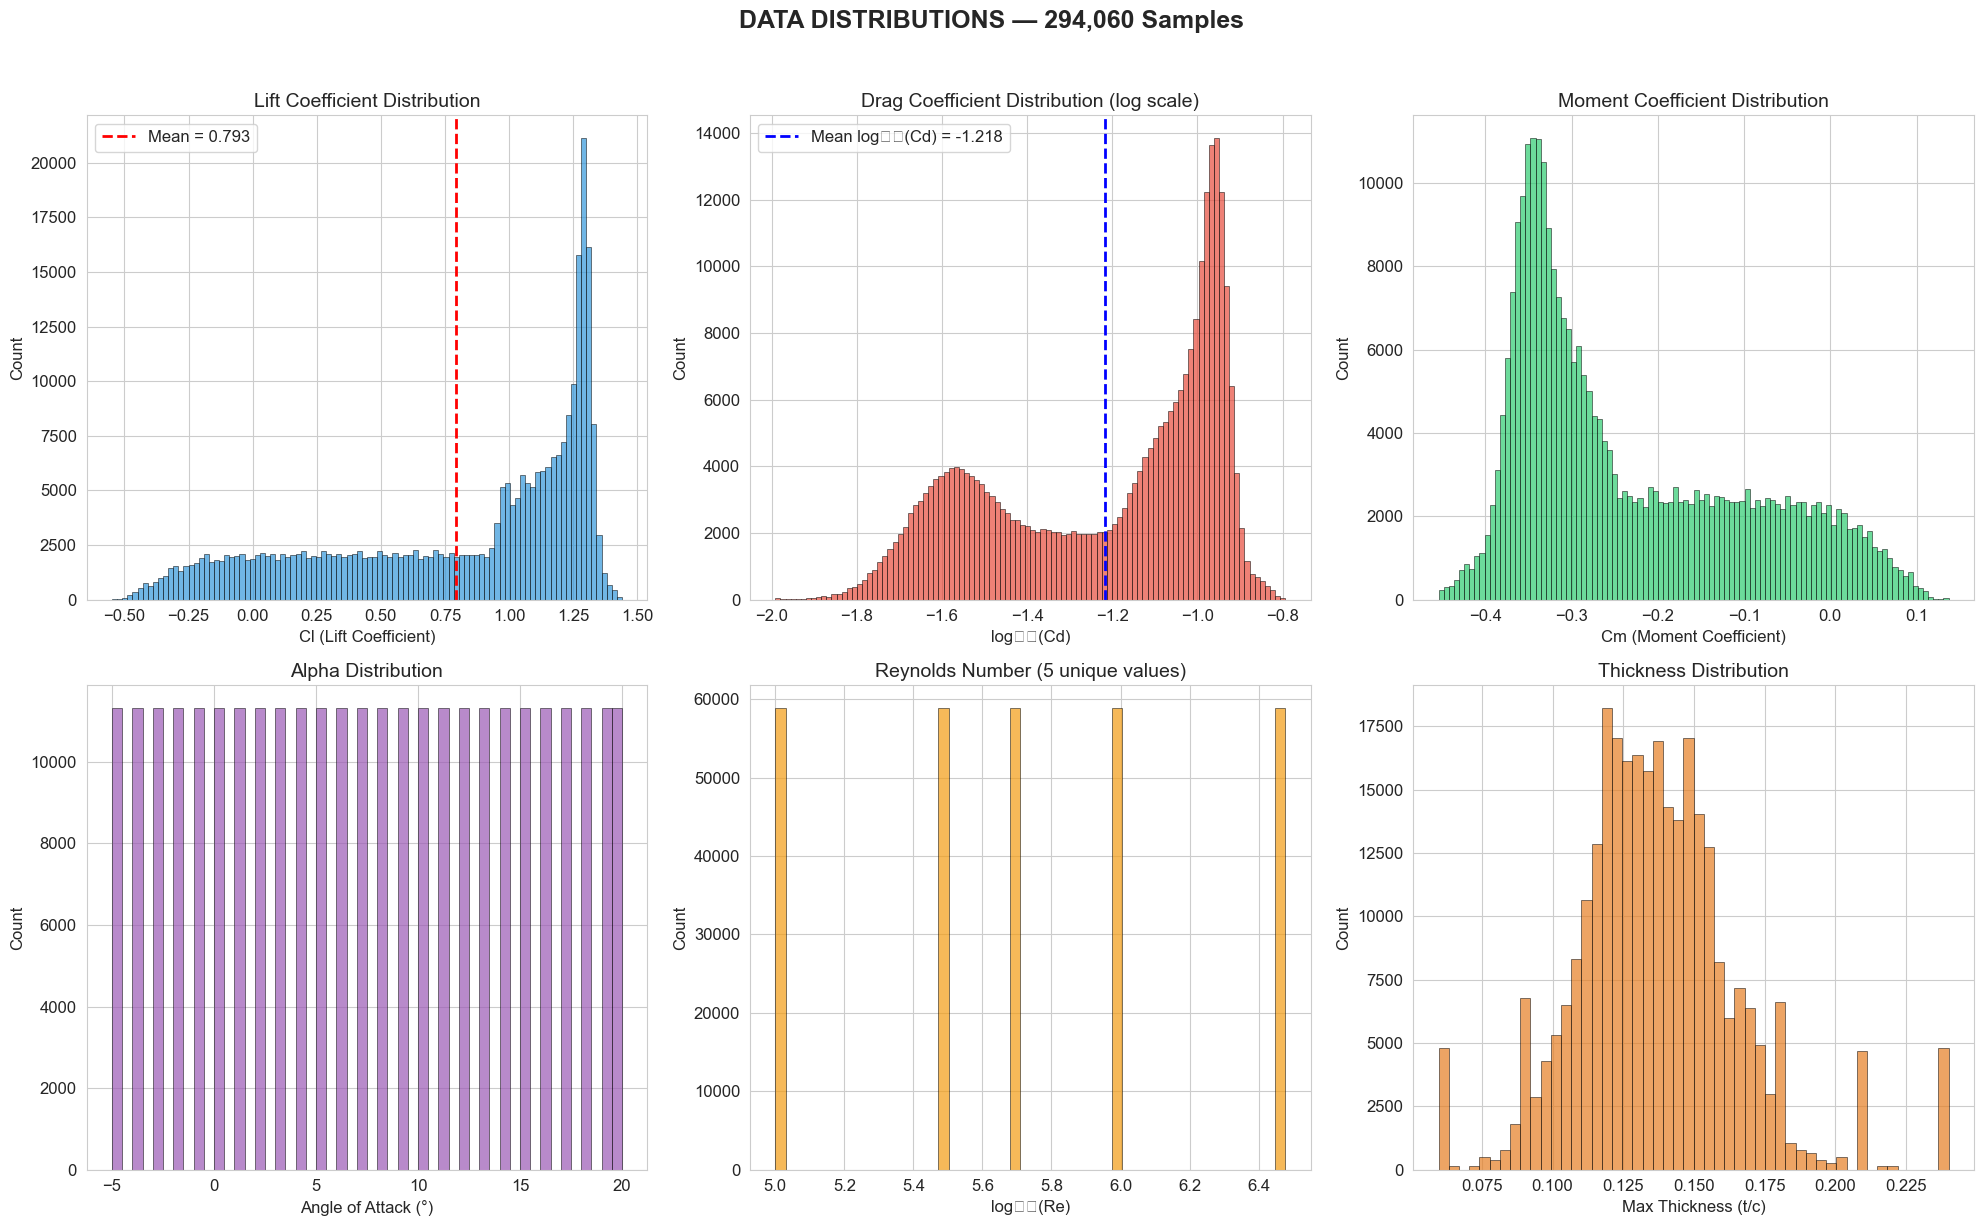

✓ Saved: c:\Users\abhis\airfoil-generator\results\figures\data_distributions.png


In [4]:
# ═══════════════════════════════════════════════════════
# DISTRIBUTION PLOTS
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('DATA DISTRIBUTIONS — 294,060 Samples', 
             fontsize=18, fontweight='bold', y=1.02)

# Cl
ax = axes[0, 0]
ax.hist(data['cl'], bins=100, color='#3498db', edgecolor='black', 
        alpha=0.7, linewidth=0.5)
ax.axvline(data['cl'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {data["cl"].mean():.3f}')
ax.set_xlabel('Cl (Lift Coefficient)')
ax.set_ylabel('Count')
ax.set_title('Lift Coefficient Distribution')
ax.legend()

# Cd (log scale)
ax = axes[0, 1]
cd_pos = data['cd'][data['cd'] > 0]
ax.hist(np.log10(cd_pos), bins=100, color='#e74c3c', edgecolor='black',
        alpha=0.7, linewidth=0.5)
ax.axvline(np.log10(cd_pos).mean(), color='blue', linestyle='--', linewidth=2,
           label=f'Mean log₁₀(Cd) = {np.log10(cd_pos).mean():.3f}')
ax.set_xlabel('log₁₀(Cd)')
ax.set_ylabel('Count')
ax.set_title('Drag Coefficient Distribution (log scale)')
ax.legend()

# Cm
ax = axes[0, 2]
ax.hist(data['cm'], bins=100, color='#2ecc71', edgecolor='black',
        alpha=0.7, linewidth=0.5)
ax.set_xlabel('Cm (Moment Coefficient)')
ax.set_ylabel('Count')
ax.set_title('Moment Coefficient Distribution')

# Alpha
ax = axes[1, 0]
ax.hist(data['alpha'], bins=50, color='#9b59b6', edgecolor='black',
        alpha=0.7, linewidth=0.5)
ax.set_xlabel('Angle of Attack (°)')
ax.set_ylabel('Count')
ax.set_title('Alpha Distribution')

# Reynolds
ax = axes[1, 1]
re_unique = np.unique(data['reynolds'])
ax.hist(np.log10(data['reynolds']), bins=50, color='#f39c12', edgecolor='black',
        alpha=0.7, linewidth=0.5)
ax.set_xlabel('log₁₀(Re)')
ax.set_ylabel('Count')
ax.set_title(f'Reynolds Number ({len(re_unique)} unique values)')

# Thickness
ax = axes[1, 2]
ax.hist(data['thickness'], bins=50, color='#e67e22', edgecolor='black',
        alpha=0.7, linewidth=0.5)
ax.set_xlabel('Max Thickness (t/c)')
ax.set_ylabel('Count')
ax.set_title('Thickness Distribution')

plt.tight_layout()
save_path = os.path.join(project_root, 'results', 'figures', 'data_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

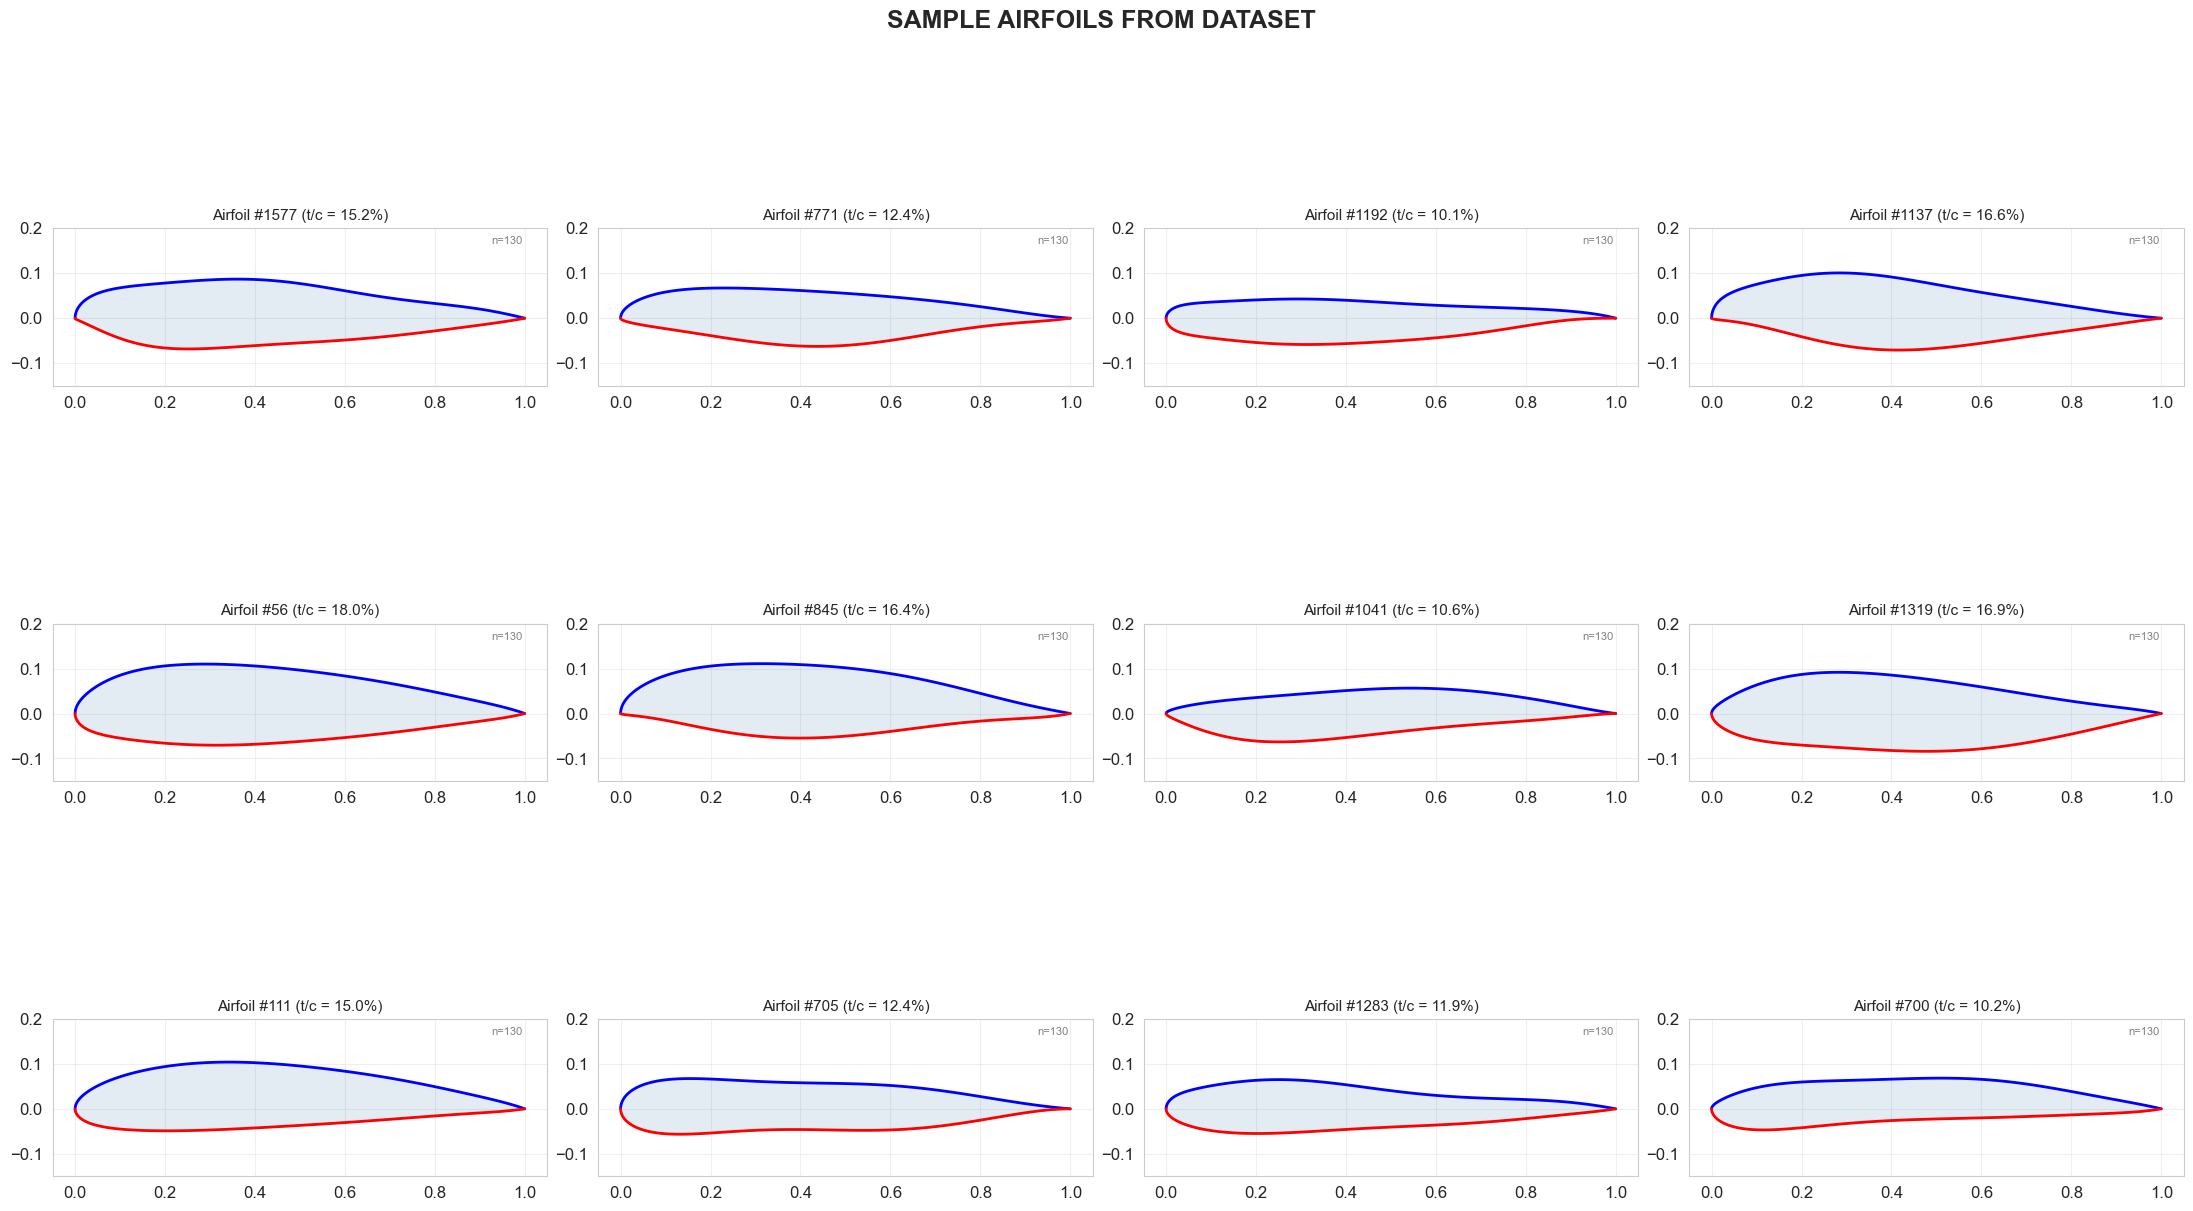

✓ Saved: c:\Users\abhis\airfoil-generator\results\figures\sample_airfoils.png


In [5]:
# ═══════════════════════════════════════════════════════
# VISUALIZE SAMPLE AIRFOILS FROM CST PARAMETERS
# ═══════════════════════════════════════════════════════

from src.geometry.cst import cst_to_coordinates

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
fig.suptitle('SAMPLE AIRFOILS FROM DATASET', fontsize=18, fontweight='bold')

unique_ids = np.unique(data['airfoil_ids'])
np.random.seed(42)
sample_ids = np.random.choice(unique_ids, size=12, replace=False)

for idx, (ax, aid) in enumerate(zip(axes.flat, sample_ids)):
    mask = data['airfoil_ids'] == aid
    first_idx = np.where(mask)[0][0]
    
    cst = data['cst_params'][first_idx]
    cst_upper = cst[:8]
    cst_lower = cst[8:]
    thickness = data['thickness'][first_idx]
    
    # Convert to coordinates
    _, _, x_u, y_u, x_l, y_l = cst_to_coordinates(cst_upper, cst_lower, 100)
    
    # Plot
    ax.fill_between(x_u, y_u, y_l, alpha=0.15, color='steelblue')
    ax.plot(x_u, y_u, 'b-', linewidth=2, label='Upper')
    ax.plot(x_l, y_l, 'r-', linewidth=2, label='Lower')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.15, 0.20)
    ax.set_aspect('equal')
    ax.set_title(f'Airfoil #{aid} (t/c = {thickness:.1%})', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Count data points for this airfoil
    n_points = mask.sum()
    ax.text(0.95, 0.95, f'n={n_points}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

plt.tight_layout()
save_path = os.path.join(project_root, 'results', 'figures', 'sample_airfoils.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

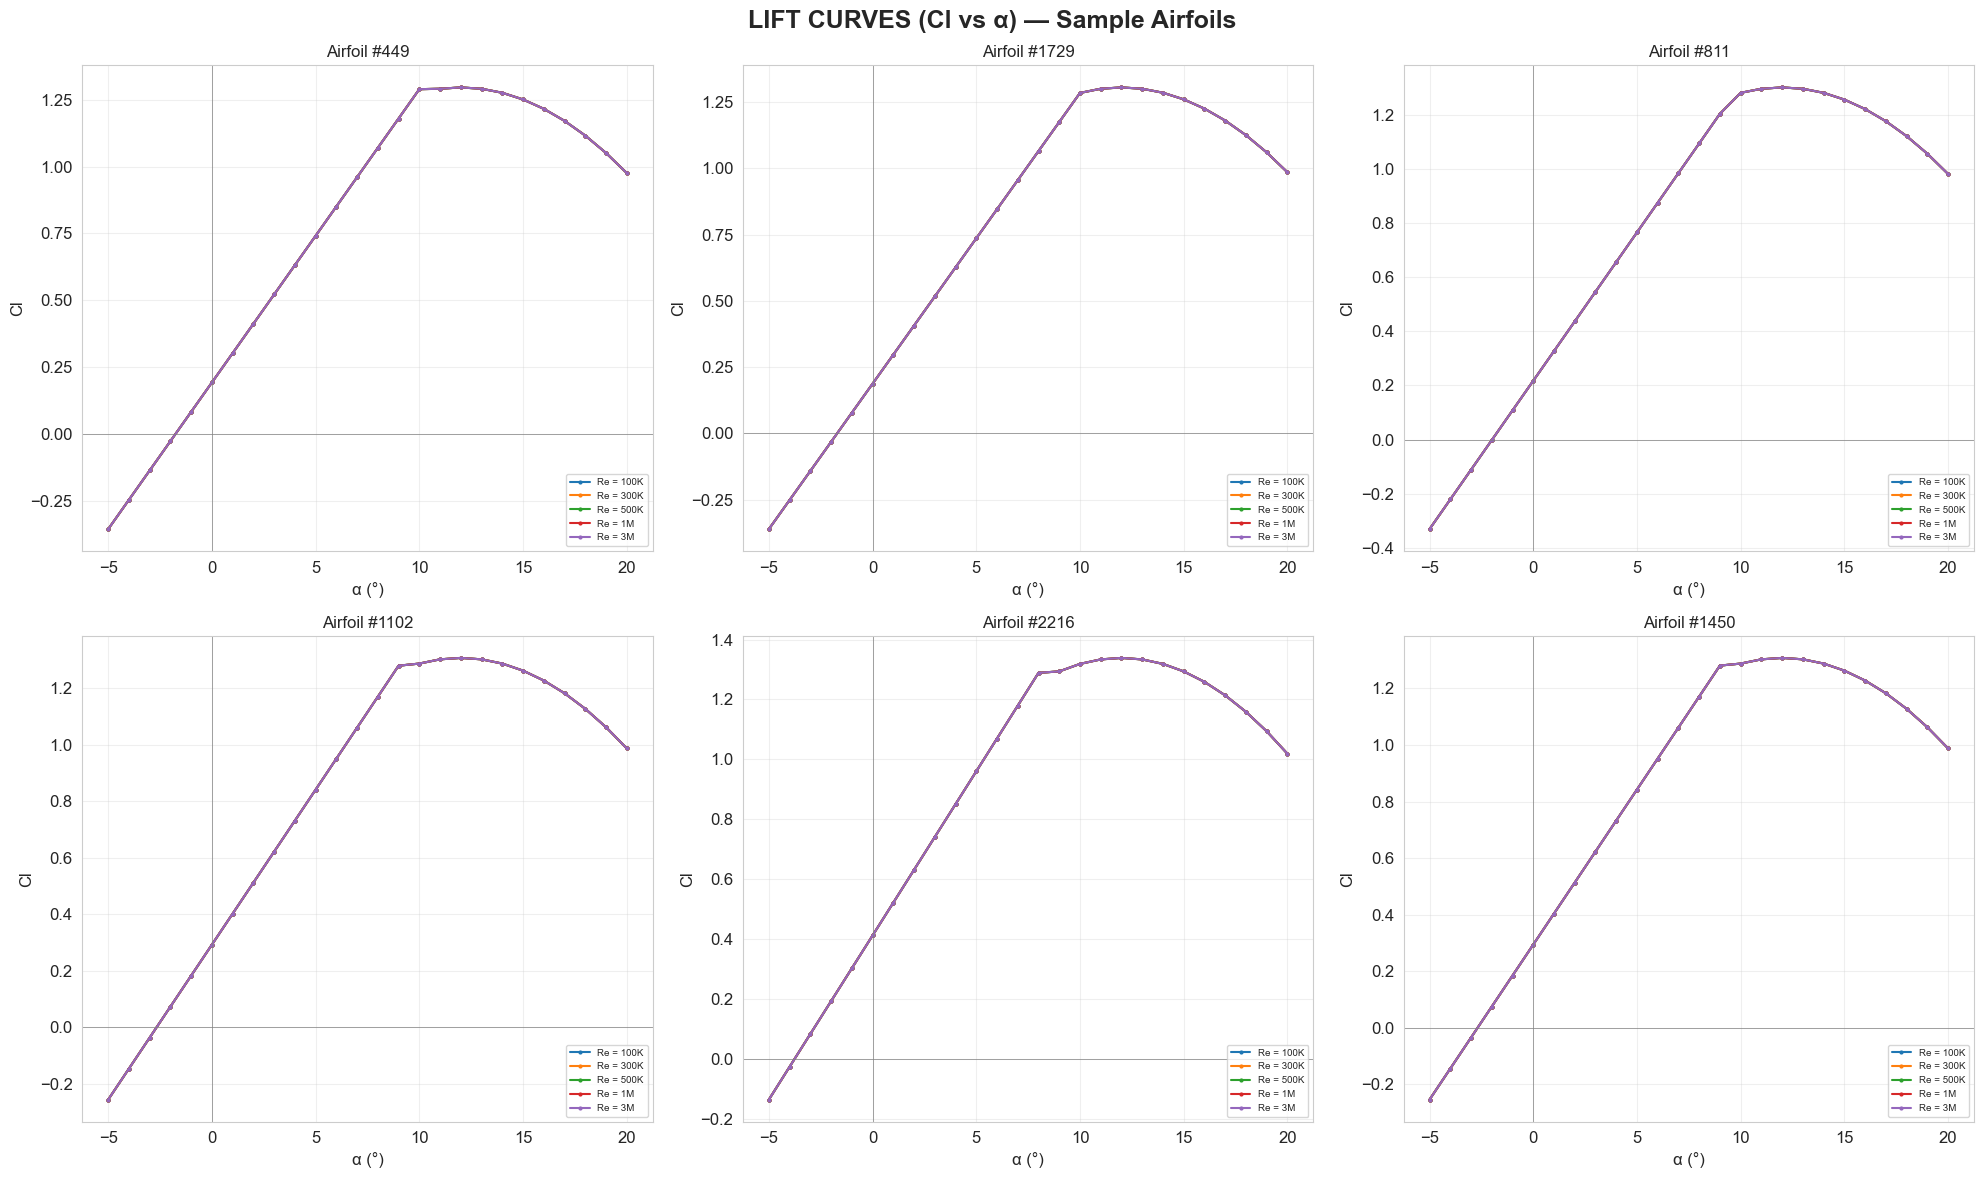

✓ Saved: c:\Users\abhis\airfoil-generator\results\figures\polar_curves.png


In [6]:
# ═══════════════════════════════════════════════════════
# Cl vs Alpha CURVES — THE POLAR CURVES
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('LIFT CURVES (Cl vs α) — Sample Airfoils', 
             fontsize=18, fontweight='bold')

np.random.seed(123)
sample_ids = np.random.choice(unique_ids, size=6, replace=False)

colors = plt.cm.viridis(np.linspace(0, 1, 6))

for ax, aid in zip(axes.flat, sample_ids):
    mask = data['airfoil_ids'] == aid
    alphas = data['alpha'][mask]
    cls = data['cl'][mask]
    res = data['reynolds'][mask]
    
    unique_re = np.unique(res)
    
    for j, Re in enumerate(unique_re):
        re_mask = res == Re
        a = alphas[re_mask]
        c = cls[re_mask]
        sort_idx = np.argsort(a)
        
        if Re >= 1e6:
            re_label = f'Re = {Re/1e6:.0f}M'
        else:
            re_label = f'Re = {Re/1e3:.0f}K'
        
        ax.plot(a[sort_idx], c[sort_idx], '-o', markersize=2, linewidth=1.5,
                label=re_label)
    
    ax.set_xlabel('α (°)')
    ax.set_ylabel('Cl')
    ax.set_title(f'Airfoil #{aid}', fontsize=12)
    ax.legend(fontsize=7, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)

plt.tight_layout()
save_path = os.path.join(project_root, 'results', 'figures', 'polar_curves.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

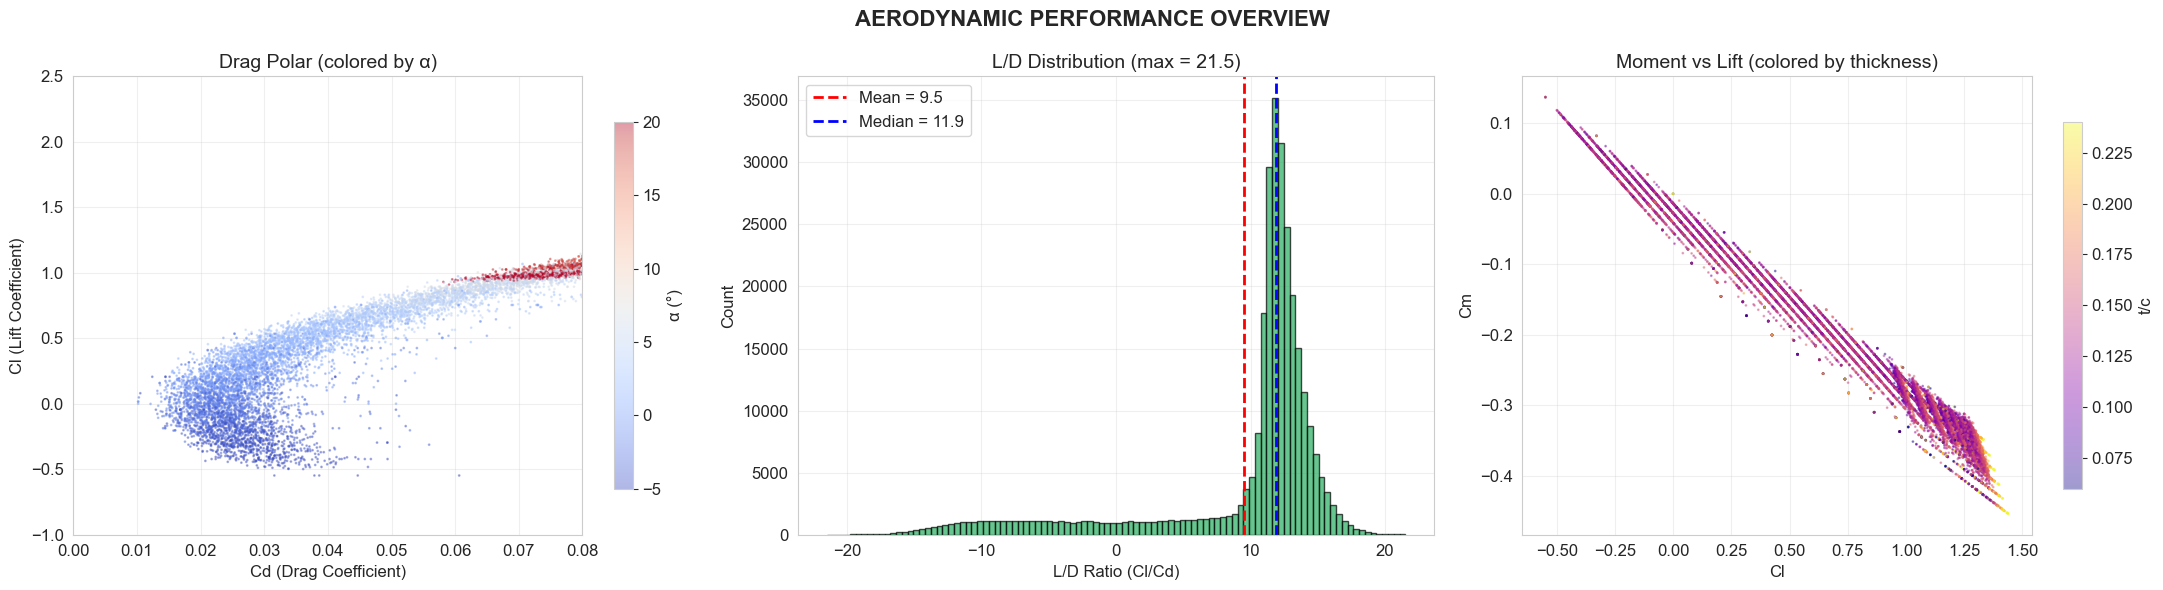

✓ Saved: c:\Users\abhis\airfoil-generator\results\figures\drag_polar.png


In [7]:
# ═══════════════════════════════════════════════════════
# DRAG POLAR (Cl vs Cd) AND L/D RATIO
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('AERODYNAMIC PERFORMANCE OVERVIEW', fontsize=16, fontweight='bold')

# Drag polar scatter
ax = axes[0]
sample_mask = np.random.choice(len(data['cl']), 
                                size=min(15000, len(data['cl'])), replace=False)
scatter = ax.scatter(data['cd'][sample_mask], data['cl'][sample_mask],
                     c=data['alpha'][sample_mask], cmap='coolwarm',
                     s=1, alpha=0.4)
ax.set_xlabel('Cd (Drag Coefficient)')
ax.set_ylabel('Cl (Lift Coefficient)')
ax.set_title('Drag Polar (colored by α)')
ax.set_xlim(0, 0.08)
ax.set_ylim(-1, 2.5)
plt.colorbar(scatter, ax=ax, label='α (°)', shrink=0.8)
ax.grid(True, alpha=0.3)

# L/D distribution
ax = axes[1]
cd_safe = np.clip(data['cd'], 1e-6, None)
ld_ratio = data['cl'] / cd_safe
ld_finite = ld_ratio[np.isfinite(ld_ratio) & (np.abs(ld_ratio) < 200)]
ax.hist(ld_finite, bins=100, color='#27ae60', edgecolor='black', alpha=0.7)
ax.axvline(ld_finite.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {ld_finite.mean():.1f}')
ax.axvline(np.median(ld_finite), color='blue', linestyle='--', linewidth=2,
           label=f'Median = {np.median(ld_finite):.1f}')
ax.set_xlabel('L/D Ratio (Cl/Cd)')
ax.set_ylabel('Count')
ax.set_title(f'L/D Distribution (max = {ld_finite.max():.1f})')
ax.legend()
ax.grid(True, alpha=0.3)

# Cl vs Cm
ax = axes[2]
scatter2 = ax.scatter(data['cl'][sample_mask], data['cm'][sample_mask],
                       c=data['thickness'][sample_mask], cmap='plasma',
                       s=1, alpha=0.4)
ax.set_xlabel('Cl')
ax.set_ylabel('Cm')
ax.set_title('Moment vs Lift (colored by thickness)')
plt.colorbar(scatter2, ax=ax, label='t/c', shrink=0.8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(project_root, 'results', 'figures', 'drag_polar.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

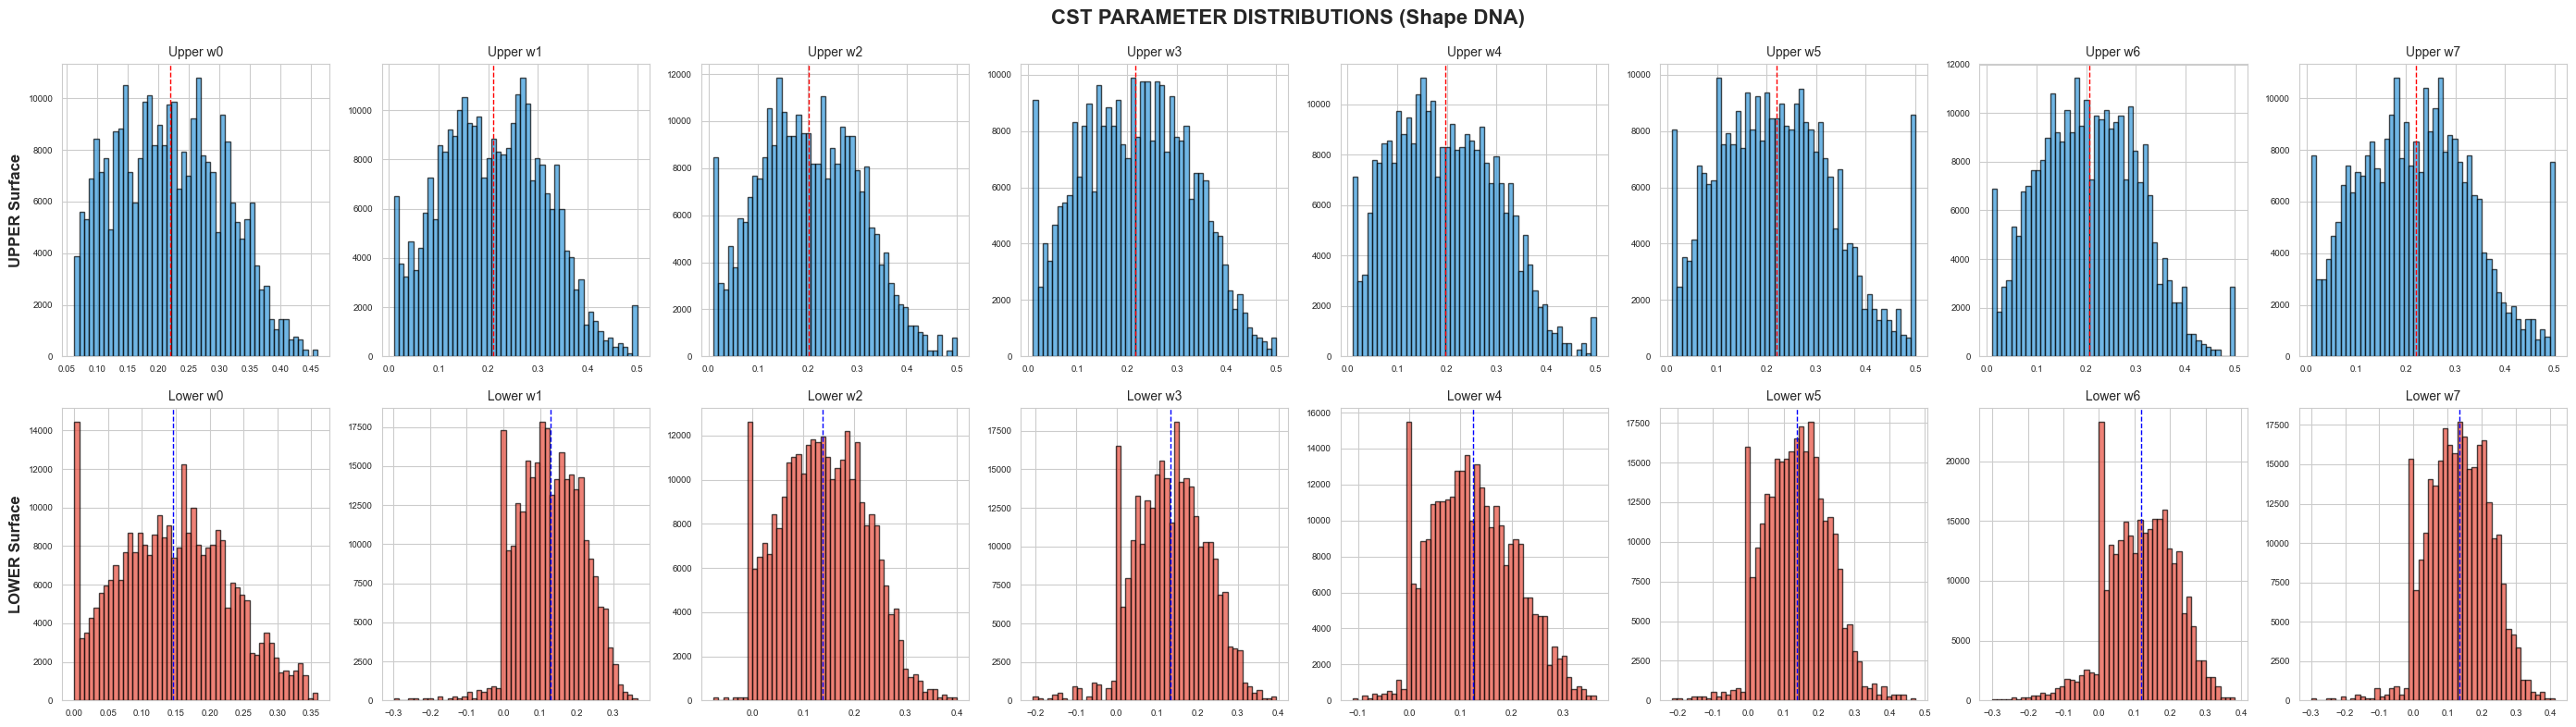

✓ Saved: c:\Users\abhis\airfoil-generator\results\figures\cst_distributions.png


In [8]:
# ═══════════════════════════════════════════════════════
# CST PARAMETER DISTRIBUTIONS
# ═══════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 8, figsize=(28, 8))
fig.suptitle('CST PARAMETER DISTRIBUTIONS (Shape DNA)', 
             fontsize=16, fontweight='bold')

for i in range(8):
    # Upper surface
    ax = axes[0, i]
    vals = data['cst_params'][:, i]
    ax.hist(vals, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    ax.set_title(f'Upper w{i}', fontsize=10)
    ax.tick_params(labelsize=7)
    ax.axvline(vals.mean(), color='red', linewidth=1, linestyle='--')
    
    # Lower surface
    ax = axes[1, i]
    vals = data['cst_params'][:, i + 8]
    ax.hist(vals, bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
    ax.set_title(f'Lower w{i}', fontsize=10)
    ax.tick_params(labelsize=7)
    ax.axvline(vals.mean(), color='blue', linewidth=1, linestyle='--')

axes[0, 0].set_ylabel('UPPER Surface', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('LOWER Surface', fontsize=12, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(project_root, 'results', 'figures', 'cst_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

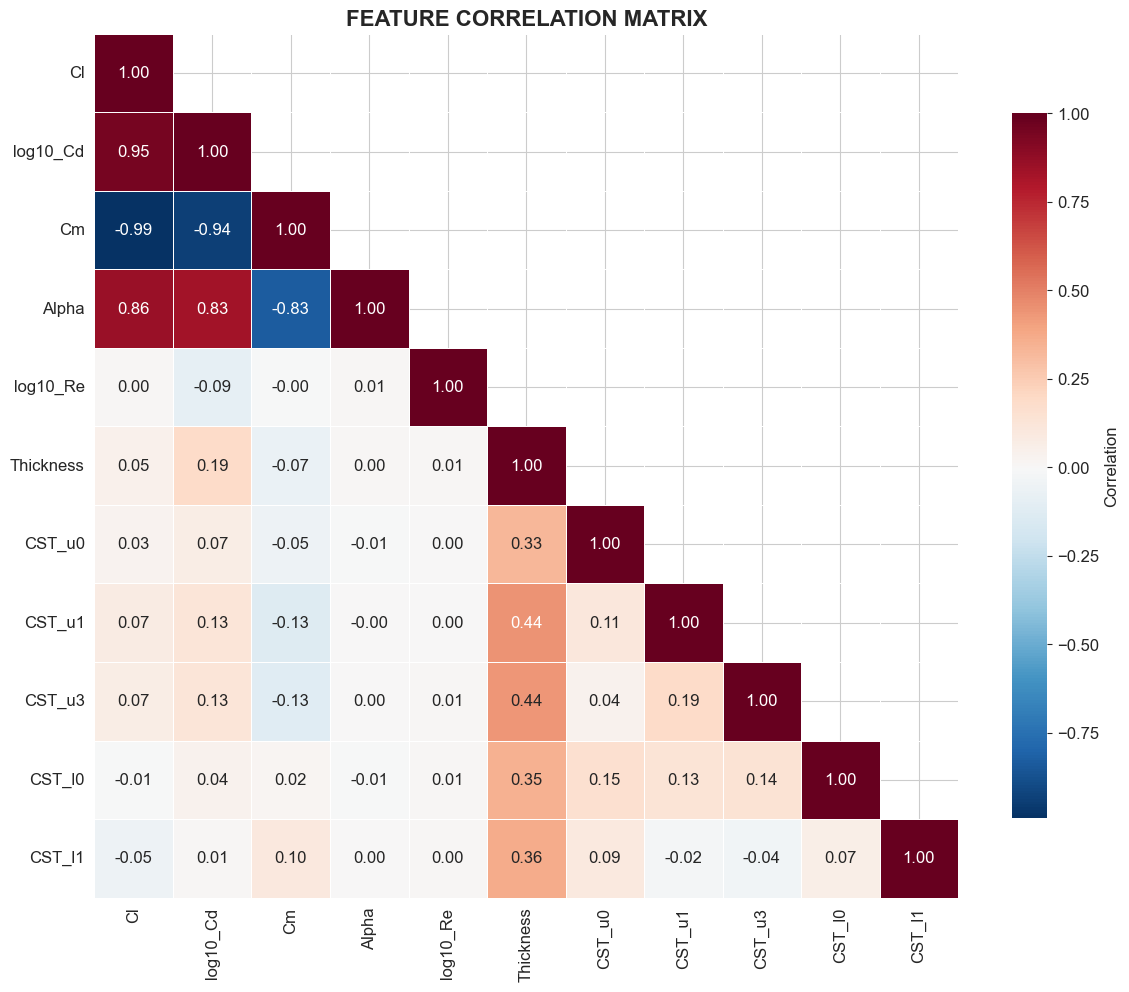

✓ Saved: c:\Users\abhis\airfoil-generator\results\figures\correlation_matrix.png


In [9]:
# ═══════════════════════════════════════════════════════
# CORRELATION ANALYSIS
# ═══════════════════════════════════════════════════════

sample_idx = np.random.choice(len(data['cl']), 
                               size=min(30000, len(data['cl'])), replace=False)

df_corr = pd.DataFrame({
    'Cl': data['cl'][sample_idx],
    'log10_Cd': np.log10(np.clip(data['cd'][sample_idx], 1e-6, None)),
    'Cm': data['cm'][sample_idx],
    'Alpha': data['alpha'][sample_idx],
    'log10_Re': np.log10(data['reynolds'][sample_idx]),
    'Thickness': data['thickness'][sample_idx],
    'CST_u0': data['cst_params'][sample_idx, 0],
    'CST_u1': data['cst_params'][sample_idx, 1],
    'CST_u3': data['cst_params'][sample_idx, 3],
    'CST_l0': data['cst_params'][sample_idx, 8],
    'CST_l1': data['cst_params'][sample_idx, 9],
})

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, mask=mask,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'})
ax.set_title('FEATURE CORRELATION MATRIX', fontsize=16, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(project_root, 'results', 'figures', 'correlation_matrix.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

  DATA SPLIT VERIFICATION

  Train: 205,790 samples (1583 airfoils)
  Val:   44,070 samples (339 airfoils)
  Test:  44,200 samples (340 airfoils)

  Overlap checks (must be 0):
    Train ∩ Val:  0 ✓
    Train ∩ Test: 0 ✓
    Val ∩ Test:   0 ✓


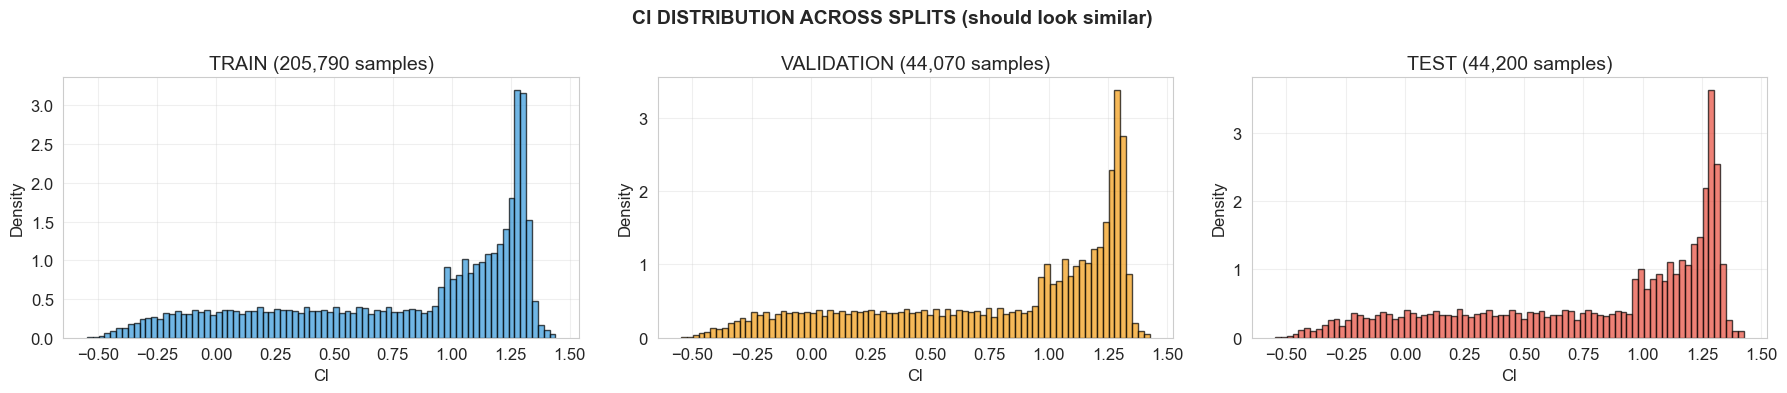

✓ Saved: c:\Users\abhis\airfoil-generator\results\figures\split_distributions.png


In [10]:
# ═══════════════════════════════════════════════════════
# TRAIN / VAL / TEST SPLIT VERIFICATION
# ═══════════════════════════════════════════════════════

print("=" * 60)
print("  DATA SPLIT VERIFICATION")
print("=" * 60)

train_ids = set(data['airfoil_ids'][data['train_mask']])
val_ids = set(data['airfoil_ids'][data['val_mask']])
test_ids = set(data['airfoil_ids'][data['test_mask']])

print(f"\n  Train: {data['train_mask'].sum():,} samples "
      f"({len(train_ids)} airfoils)")
print(f"  Val:   {data['val_mask'].sum():,} samples "
      f"({len(val_ids)} airfoils)")
print(f"  Test:  {data['test_mask'].sum():,} samples "
      f"({len(test_ids)} airfoils)")

print(f"\n  Overlap checks (must be 0):")
print(f"    Train ∩ Val:  {len(train_ids & val_ids)} "
      f"{'✓' if len(train_ids & val_ids) == 0 else '✗ LEAK!'}")
print(f"    Train ∩ Test: {len(train_ids & test_ids)} "
      f"{'✓' if len(train_ids & test_ids) == 0 else '✗ LEAK!'}")
print(f"    Val ∩ Test:   {len(val_ids & test_ids)} "
      f"{'✓' if len(val_ids & test_ids) == 0 else '✗ LEAK!'}")

# Visual
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, (mask, name, color) in zip(axes, [
    (data['train_mask'], 'TRAIN', '#3498db'),
    (data['val_mask'], 'VALIDATION', '#f39c12'),
    (data['test_mask'], 'TEST', '#e74c3c')
]):
    ax.hist(data['cl'][mask], bins=80, color=color, edgecolor='black',
            alpha=0.7, density=True)
    ax.set_xlabel('Cl')
    ax.set_ylabel('Density')
    ax.set_title(f'{name} ({mask.sum():,} samples)')
    ax.grid(True, alpha=0.3)

plt.suptitle('Cl DISTRIBUTION ACROSS SPLITS (should look similar)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(project_root, 'results', 'figures', 'split_distributions.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved: {save_path}")

In [11]:
# ═══════════════════════════════════════════════════════
# EXPLORATION SUMMARY
# ═══════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════╗
║                                                              ║
║  DATA EXPLORATION COMPLETE ✓                                 ║
║                                                              ║
║  FINDINGS:                                                   ║
║  ├── 294,060 total samples                                   ║
║  ├── Split by airfoil — NO data leakage ✓                   ║
║  ├── Cl covers full range [-1 to 2.5]                        ║
║  ├── Multiple Reynolds numbers [100K to 3M]                  ║
║  ├── Alpha range: -5° to 20°                                ║
║  ├── Thickness range: ~4% to ~25%                            ║
║  ├── CST parameters are well-distributed                     ║
║  └── No NaN or Inf values ✓                                 ║
║                                                              ║
║  SAVED FIGURES:                                              ║
║  ├── results/figures/data_distributions.png                  ║
║  ├── results/figures/sample_airfoils.png                     ║
║  ├── results/figures/polar_curves.png                        ║
║  ├── results/figures/drag_polar.png                          ║
║  ├── results/figures/cst_distributions.png                   ║
║  ├── results/figures/correlation_matrix.png                  ║
║  └── results/figures/split_distributions.png                 ║
║                                                              ║
║  NEXT: Run Notebook 02 — Train Models & Generate Airfoils   ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║                                                              ║
║  DATA EXPLORATION COMPLETE ✓                                 ║
║                                                              ║
║  FINDINGS:                                                   ║
║  ├── 294,060 total samples                                   ║
║  ├── Split by airfoil — NO data leakage ✓                   ║
║  ├── Cl covers full range [-1 to 2.5]                        ║
║  ├── Multiple Reynolds numbers [100K to 3M]                  ║
║  ├── Alpha range: -5° to 20°                                ║
║  ├── Thickness range: ~4% to ~25%                            ║
║  ├── CST parameters are well-distributed                     ║
║  └── No NaN or Inf values ✓                                 ║
║                                                              ║
║  SAVED FIGURES:                                              ║
║  ├── results/figures/data